# Compare Image vs Photometry-Only CFM Models (Experimental)

Post-training analysis comparing the **experimental** models:
- **Image + Photometry model** (`ImprovedConditionalFlowModel`) — ImageEncoder + 5-layer 512-wide ImprovedVelocityNet
- **Photometry-only model** (`ImprovedPhotometryConditionalFlowModelSimple`) — 5-layer 512-wide ImprovedVelocityNet

Both models use raw scalar `t` (no sinusoidal time embeddings) and were trained with scaled learning rate (`lr = 1e-5 × num_gpus`).

## Outputs:
1. True vs Predicted scatter plots for all 9 galaxy properties
2. Corner plot overlaying test data with posterior medians from both models

In [1]:
from cfm_models import ImprovedConditionalFlowModel, ImprovedPhotometryConditionalFlowModelSimple
from cfm_utils import sample_properties_distribution_rk4, sample_properties_rk4, compute_posterior_metrics
from cfm_plot_utils import plot_posterior_metrics_histogram

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from astropy.io import fits
import h5py
import os
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import corner
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split

# Preprocessing (identical to training notebooks)

In [2]:
# Load the FastSpecFit FITS file
fits_path = Path("fastspec-iron.fits")

def to_native(arr):
    """Ensure a NumPy array is in native-endian dtype."""
    a = np.asarray(arr)
    if a.dtype.kind in "fiu":
        if a.dtype.byteorder == '>' or (a.dtype.byteorder == '=' and not np.little_endian):
            return a.byteswap().view(a.dtype.newbyteorder("="))
    return a

print("Loading FastSpecFit FITS file and applying preprocessing...")

Loading FastSpecFit FITS file and applying preprocessing...


In [3]:
# Load and filter FITS data
print("\nLoading HDU[1] (FASTSPEC) properties...")
with fits.open(fits_path, memmap=True) as hdul:
    fastspec_data = hdul[1].data
    
    print("Loading columns: Z, LOGMSTAR, SFR, DN4000, AV, HBETA_FLUX, OIII_5007_FLUX, HALPHA_FLUX, NII_6584_FLUX")
    
    df_hdu1 = pd.DataFrame({
        'TARGETID': to_native(fastspec_data['TARGETID']),
        'Z': to_native(fastspec_data['Z']),
        'LOGMSTAR': to_native(fastspec_data['LOGMSTAR']),
        'SFR': to_native(fastspec_data['SFR']),
        'DN4000': to_native(fastspec_data['DN4000']),
        'AV': to_native(fastspec_data['AV']),
        'HBETA_FLUX': to_native(fastspec_data['HBETA_FLUX']),
        'OIII_5007_FLUX': to_native(fastspec_data['OIII_5007_FLUX']),
        'HALPHA_FLUX': to_native(fastspec_data['HALPHA_FLUX']),
        'NII_6584_FLUX': to_native(fastspec_data['NII_6584_FLUX'])
    })
    
    print(f"Loaded {len(df_hdu1)} galaxies from HDU[1]")

print("\nLoading HDU[2] (METADATA) photometry...")
with fits.open(fits_path, memmap=True) as hdul:
    metadata_data = hdul[2].data
    
    df_hdu2 = pd.DataFrame({
        'TARGETID': to_native(metadata_data['TARGETID']),
        'SPECTYPE': np.char.strip(metadata_data['SPECTYPE'].astype(str)),
        'ZWARN': to_native(metadata_data['ZWARN']),
        'FLUX_G': to_native(metadata_data['FLUX_G']),
        'FLUX_R': to_native(metadata_data['FLUX_R']),
        'FLUX_Z': to_native(metadata_data['FLUX_Z']),
        'FLUX_W1': to_native(metadata_data['FLUX_W1']),
        'FLUX_W2': to_native(metadata_data['FLUX_W2'])
    })
    
    print(f"Loaded {len(df_hdu2)} galaxies from HDU[2]")

# Check for duplicate TARGETIDs
print("\nChecking for duplicate TARGETIDs...")
n_dup_hdu1 = df_hdu1['TARGETID'].duplicated().sum()
n_dup_hdu2 = df_hdu2['TARGETID'].duplicated().sum()
print(f"  HDU[1] duplicates: {n_dup_hdu1}")
print(f"  HDU[2] duplicates: {n_dup_hdu2}")

if n_dup_hdu1 > 0:
    df_hdu1 = df_hdu1.drop_duplicates(subset='TARGETID', keep='first').reset_index(drop=True)
if n_dup_hdu2 > 0:
    df_hdu2 = df_hdu2.drop_duplicates(subset='TARGETID', keep='first').reset_index(drop=True)

# Merge
print("\nMerging HDU[1] and HDU[2] by TARGETID...")
df_merged = pd.merge(df_hdu1, df_hdu2, on='TARGETID', how='inner')
print(f"Common targets in both HDUs: {len(df_merged)}")

# Apply quality cuts
print("\nApplying quality cuts...")

mask = (
    (df_merged['SPECTYPE'] == 'GALAXY') & 
    (df_merged['ZWARN'] == 0) &
    (df_merged['Z'] > 0.02) &
    (df_merged['Z'] < 0.31) &
    (df_merged['DN4000'] >= 0) &
    (df_merged['DN4000'] <= 5) &
    df_merged.notna().all(axis=1)
)

df = df_merged[mask].reset_index(drop=True)
df = df.sample(frac=1, random_state=32).reset_index(drop=True)

print(f"After all cuts: {df.shape[0]} galaxies")
print(f"Cut statistics:")
print(f"  Z in [0.02, 0.31]: {((df_merged['Z'] > 0.02) & (df_merged['Z'] < 0.31)).sum()}")
print(f"  DN4000 in [0, 5]: {((df_merged['DN4000'] >= 0) & (df_merged['DN4000'] <= 5)).sum()}")
print(f"  All cuts combined: {mask.sum()}")


Loading HDU[1] (FASTSPEC) properties...
Loading columns: Z, LOGMSTAR, SFR, DN4000, AV, HBETA_FLUX, OIII_5007_FLUX, HALPHA_FLUX, NII_6584_FLUX
Loaded 17995820 galaxies from HDU[1]

Loading HDU[2] (METADATA) photometry...
Loaded 17995820 galaxies from HDU[2]

Checking for duplicate TARGETIDs...
  HDU[1] duplicates: 633659
  HDU[2] duplicates: 633659

Merging HDU[1] and HDU[2] by TARGETID...
Common targets in both HDUs: 17362161

Applying quality cuts...
After all cuts: 5257378 galaxies
Cut statistics:
  Z in [0.02, 0.31]: 5622892
  DN4000 in [0, 5]: 17212869
  All cuts combined: 5257378


In [4]:
# Build properties (9 dimensions)
# Z (redshift), LOGMSTAR, log(SFR), DN4000, AV, log(1+HBETA_FLUX), log(1+OIII_5007_FLUX), log(1+HALPHA_FLUX), log(1+NII_6584_FLUX)
redshift = df['Z'].values
logM = df['LOGMSTAR'].values
logSFR = np.log10(df['SFR'].values)
dn4000 = df['DN4000'].values
Av = df['AV'].values
hbeta_flux = np.log10(1 + df['HBETA_FLUX'].values)
oiii_flux = np.log10(1 + df['OIII_5007_FLUX'].values)
halpha_flux = np.log10(1 + df['HALPHA_FLUX'].values)
nii_flux = np.log10(1 + df['NII_6584_FLUX'].values)

unnorm_props = np.column_stack([redshift, logM, logSFR, dn4000, Av, hbeta_flux, oiii_flux, halpha_flux, nii_flux])

# Check for non-finite values
if not np.isfinite(unnorm_props).all():
    n_bad = (~np.isfinite(unnorm_props)).sum()
    print(f"Warning: {n_bad} non-finite values in properties, filtering...")
    finite_mask2 = np.isfinite(unnorm_props).all(axis=1)
    df = df[finite_mask2].reset_index(drop=True)
    unnorm_props = unnorm_props[finite_mask2]
    redshift, logM, logSFR, dn4000, Av, hbeta_flux, oiii_flux, halpha_flux, nii_flux = unnorm_props.T

print(f"After property filtering: {df.shape[0]} galaxies")

/tmp/ipykernel_7400/3280113212.py:5: RuntimeWarning: divide by zero encountered in log10
  logSFR = np.log10(df['SFR'].values)


After property filtering: 3934572 galaxies


In [5]:
# dr2_rgb function from John Wu
def sdss_rgb(imgs, bands, scales=None, m=0.02):
    rgbscales = {'u': (2,1.5),
                 'g': (2,2.5),
                 'r': (1,1.5),
                 'i': (0,1.0),
                 'z': (0,0.4),
                 }
    if scales is not None:
        rgbscales.update(scales)

    I = 0
    for img,band in zip(imgs, bands):
        plane,scale = rgbscales[band]
        img = np.maximum(0, img * scale + m)
        I = I + img
    I /= len(bands)
        
    Q = 20
    fI = np.arcsinh(Q * I) / np.sqrt(Q)
    I += (I == 0.) * 1e-6
    H,W = I.shape
    rgb = np.zeros((H,W,3), np.float32)
    for img,band in zip(imgs, bands):
        plane,scale = rgbscales[band]
        rgb[:,:,plane] = (img * scale + m) * fI / I

    rgb = np.clip(rgb, 0, 1)
    return rgb

def dr2_rgb(rimgs, bands, **ignored):
    return sdss_rgb(rimgs, bands, scales=dict(g=(2,6.0), r=(1,3.4), z=(0,2.2)), m=0.03)

# Cross-reference with h5 file, extract images, build datasets

In [6]:
# Open H5 file and cross-reference with FITS
h5_file = '../astroclip_desi.1.1.5.h5'
f = h5py.File(h5_file, 'r')

all_h5_targetids = []
for group_key in f.keys():
    all_h5_targetids.append(f[group_key]['targetids'][:])
all_h5_targetids = np.concatenate(all_h5_targetids)

print(f"Total galaxies in h5 file: {len(all_h5_targetids)}")
print(f"Unique galaxies in h5 file: {len(np.unique(all_h5_targetids))}")

# Cross-reference
fits_targetids = df['TARGETID'].values
h5_targetids_set = set(all_h5_targetids)
in_h5 = np.array([tid in h5_targetids_set for tid in fits_targetids])
df_final = df[in_h5].reset_index(drop=True)

print(f"\nGalaxies in both FITS and h5: {len(df_final)}")

# Build property arrays from df_final (9 dimensions) with log(1+flux) for emission lines
redshift_final = df_final['Z'].values
logM_final = df_final['LOGMSTAR'].values
logSFR_final = np.log10(df_final['SFR'].values)
dn4000_final = df_final['DN4000'].values
Av_final = df_final['AV'].values
hbeta_flux_final = np.log10(1 + df_final['HBETA_FLUX'].values)
oiii_flux_final = np.log10(1 + df_final['OIII_5007_FLUX'].values)
halpha_flux_final = np.log10(1 + df_final['HALPHA_FLUX'].values)
nii_flux_final = np.log10(1 + df_final['NII_6584_FLUX'].values)

properties = np.column_stack([
    redshift_final, logM_final, logSFR_final, dn4000_final, Av_final,
    hbeta_flux_final, oiii_flux_final, halpha_flux_final, nii_flux_final
])

# Normalize properties
prop_mean = properties.mean(axis=0)
prop_std = properties.std(axis=0)
tab_dataset = (properties - prop_mean) / prop_std

print(f"\nProperties shape: {tab_dataset.shape}")
print(f"Property means: {prop_mean}")
print(f"Property stds: {prop_std}")
print(f"Property names: ['Z', 'log(M*)', 'log(SFR)', 'DN4000', 'AV', 'log(1+HBETA)', 'log(1+OIII)', 'log(1+HALPHA)', 'log(1+NII)']")

# Prepare photometry
print("\nPreparing photometry conditioning (5 bands: G, R, Z, W1, W2)...")
photometry_array = np.column_stack([
    df_final['FLUX_G'].values,
    df_final['FLUX_R'].values,
    df_final['FLUX_Z'].values,
    df_final['FLUX_W1'].values,
    df_final['FLUX_W2'].values
])

mags = 22.5 - 2.5 * np.log10(np.maximum(photometry_array, 1e-10))
mags_mean = mags.mean(axis=0)
mags_std = mags.std(axis=0)
phot_dataset = (mags - mags_mean) / mags_std

print(f"Photometry shape: {phot_dataset.shape}")

Total galaxies in h5 file: 197976
Unique galaxies in h5 file: 197976

Galaxies in both FITS and h5: 101291

Properties shape: (101291, 9)
Property means: [ 0.19164507 10.11076435 -0.64271024  1.4841489   0.37317761  0.93099276
  0.85916145  1.42817571  1.12591911]
Property stds: [0.07290728 0.66346609 0.69573988 0.33307407 0.50865346 0.51486937
 0.52108967 0.65086451 0.45660255]
Property names: ['Z', 'log(M*)', 'log(SFR)', 'DN4000', 'AV', 'log(1+HBETA)', 'log(1+OIII)', 'log(1+HALPHA)', 'log(1+NII)']

Preparing photometry conditioning (5 bands: G, R, Z, W1, W2)...
Photometry shape: (101291, 5)


In [7]:
# Extract images from h5 file for df_final target IDs
final_targetids = df_final['TARGETID'].values
n_final = len(final_targetids)

# Create a mapping from targetid to h5 group and index
targetid_to_location = {}
for group_key in f.keys():
    group_targetids = f[group_key]['targetids'][:]
    for idx, tid in enumerate(group_targetids):
        targetid_to_location[tid] = (group_key, idx)

# Pre-allocate arrays
image_size = 152
images_array = np.zeros((n_final, image_size, image_size, 3), dtype=np.float32)

# Extract data
print("Extracting images from h5 file...")
for i, tid in enumerate(tqdm(final_targetids)):
    if tid in targetid_to_location:
        group_key, idx = targetid_to_location[tid]
        images_array[i] = f[group_key]['images'][idx]
    else:
        print(f"Warning: targetid {tid} not found in h5 file")

print(f"\nOriginal images shape: {images_array.shape}")

Extracting images from h5 file...


100%|██████████| 101291/101291 [01:51<00:00, 911.49it/s]


Original images shape: (101291, 152, 152, 3)


In [8]:
# Pre-compute dr2_rgb transformations
print("Pre-computing dr2_rgb transformations...")
images_rgb = np.zeros((n_final, 3, image_size, image_size), dtype=np.float32)
for i in tqdm(range(n_final), desc="Applying dr2_rgb"):
    img_grz = images_array[i]  # (H, W, 3) in g,r,z order
    img_rgb = dr2_rgb(img_grz.transpose(2, 0, 1), bands=["g", "r", "z"])  # (H, W, 3)
    images_rgb[i] = img_rgb.transpose(2, 0, 1)  # (3, H, W) for PyTorch

print(f"Transformed RGB images shape: {images_rgb.shape}")

f.close()

Pre-computing dr2_rgb transformations...


Applying dr2_rgb: 100%|██████████| 101291/101291 [02:34<00:00, 655.13it/s]

Transformed RGB images shape: (101291, 3, 152, 152)


# Create Train/Val/Test Split and Load Models

In [9]:
class GalaxyDataset(Dataset):
    def __init__(self, images_rgb, photometry, properties, indices):
        self.images_rgb = images_rgb
        self.photometry = photometry
        self.properties = properties
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        img_tensor = torch.from_numpy(self.images_rgb[actual_idx]).float()
        phot = torch.from_numpy(self.photometry[actual_idx]).float()
        prop = torch.from_numpy(self.properties[actual_idx]).float()
        return img_tensor, phot, prop

# Create train/val/test splits (same random_state as training)
num_samples = len(images_rgb)
indices = np.arange(num_samples)

train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=32)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=32)

print(f"Dataset split:")
print(f"  Training:   {len(train_idx):6d} samples")
print(f"  Validation: {len(val_idx):6d} samples")
print(f"  Test:       {len(test_idx):6d} samples")

train_dataset = GalaxyDataset(images_rgb, phot_dataset, tab_dataset, train_idx)
val_dataset = GalaxyDataset(images_rgb, phot_dataset, tab_dataset, val_idx)
test_dataset = GalaxyDataset(images_rgb, phot_dataset, tab_dataset, test_idx)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

print(f"\nAll datasets and loaders created.")

Dataset split:
  Training:    81032 samples
  Validation:  10129 samples
  Test:        10130 samples

All datasets and loaders created.


In [10]:
# Model dimensions
num_vars = tab_dataset.shape[1]  # 9 properties
phot_dim = phot_dataset.shape[1]  # 5 photometry features
feature_dim = 256  # image encoder output dimension

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load experimental image model (ImprovedConditionalFlowModel)
print("\nLoading experimental image model...")
image_model = ImprovedConditionalFlowModel(
    property_dim=num_vars,
    feature_dim=feature_dim,
    phot_dim=phot_dim,
    hidden_dim=512
).to(device)

image_model_path = "models/best_image_model_FSFV2_9props_sigma1eneg4.pth"
image_model.load_state_dict(torch.load(image_model_path, map_location=device))
image_model.eval()
print(f"Loaded image model from {image_model_path}")

# Load experimental photometry model (ImprovedPhotometryConditionalFlowModelSimple)
print("\nLoading experimental photometry model...")
phot_model = ImprovedPhotometryConditionalFlowModelSimple(
    phot_dim=phot_dim,
    property_dim=num_vars,
    hidden_dim=512
).to(device)

phot_model_path = "models/best_photometry_model_FSFV2_9props_sigma1eneg4.pth"
phot_model.load_state_dict(torch.load(phot_model_path, map_location=device))
phot_model.eval()
print(f"Loaded photometry model from {phot_model_path}")

print("\n" + "="*60)
print("Both experimental models loaded successfully!")
print("="*60)

Using device: cuda

Loading experimental image model...
Loaded image model from models/best_image_model_FSFV2_9props_sigma1eneg4.pth

Loading experimental photometry model...
Loaded photometry model from models/best_photometry_model_FSFV2_9props_sigma1eneg4.pth

Both experimental models loaded successfully!


In [11]:
# Evaluate CFM losses (train/val/test) for both models
import torch.nn as nn

sigma = 1e-4
mse_loss = nn.MSELoss()

def evaluate_cfm_loss_image(loader, model, device, num_vars):
    """Evaluate CFM velocity-matching loss for the image+photometry model."""
    model.eval()
    total = 0.0
    with torch.no_grad():
        for img, phot, prop in loader:
            bsz = img.size(0)
            img, phot, prop = img.to(device), phot.to(device), prop.to(device)
            x0 = torch.randn(bsz, num_vars, device=device)
            t = torch.rand(bsz, 1, device=device)
            mu = (1-t)*x0 + t*prop
            x = mu + sigma*torch.randn_like(mu)
            target = prop - x0
            pred = model(t, x, img, phot)
            loss = mse_loss(pred, target)
            total += loss.item() * bsz
    return total / len(loader.dataset)

def evaluate_cfm_loss_phot(loader, model, device, num_vars):
    """Evaluate CFM velocity-matching loss for the photometry-only model."""
    model.eval()
    total = 0.0
    with torch.no_grad():
        for img, phot, prop in loader:
            bsz = phot.size(0)
            phot, prop = phot.to(device), prop.to(device)
            x0 = torch.randn(bsz, num_vars, device=device)
            t = torch.rand(bsz, 1, device=device)
            mu = (1-t)*x0 + t*prop
            x = mu + sigma*torch.randn_like(mu)
            target = prop - x0
            pred = model(t, x, phot)
            loss = mse_loss(pred, target)
            total += loss.item() * bsz
    return total / len(loader.dataset)

print("Evaluating CFM losses on train/val/test splits...")
print("(Using sigma=1e-4, random t and x0 — values will vary slightly between runs)\n")

# Image model losses
print("Image + Photometry Model (ImprovedConditionalFlowModel):")
train_loss_img = evaluate_cfm_loss_image(train_loader, image_model, device, num_vars)
val_loss_img = evaluate_cfm_loss_image(val_loader, image_model, device, num_vars)
test_loss_img = evaluate_cfm_loss_image(test_loader, image_model, device, num_vars)
print(f"  Train Loss: {train_loss_img:.4f}")
print(f"  Val Loss:   {val_loss_img:.4f}")
print(f"  Test Loss:  {test_loss_img:.4f}")

# Photometry model losses
print(f"\nPhotometry-Only Model (ImprovedPhotometryConditionalFlowModelSimple):")
train_loss_phot = evaluate_cfm_loss_phot(train_loader, phot_model, device, num_vars)
val_loss_phot = evaluate_cfm_loss_phot(val_loader, phot_model, device, num_vars)
test_loss_phot = evaluate_cfm_loss_phot(test_loader, phot_model, device, num_vars)
print(f"  Train Loss: {train_loss_phot:.4f}")
print(f"  Val Loss:   {val_loss_phot:.4f}")
print(f"  Test Loss:  {test_loss_phot:.4f}")

# Summary comparison
print(f"\n{'='*60}")
print(f"{'Split':<10} {'Image+Phot':<15} {'Phot-Only':<15} {'Diff (Img-Phot)':<15}")
print(f"{'-'*60}")
print(f"{'Train':<10} {train_loss_img:<15.4f} {train_loss_phot:<15.4f} {train_loss_img - train_loss_phot:<15.4f}")
print(f"{'Val':<10} {val_loss_img:<15.4f} {val_loss_phot:<15.4f} {val_loss_img - val_loss_phot:<15.4f}")
print(f"{'Test':<10} {test_loss_img:<15.4f} {test_loss_phot:<15.4f} {test_loss_img - test_loss_phot:<15.4f}")
print(f"{'='*60}")

Evaluating CFM losses on train/val/test splits...
(Using sigma=1e-4, random t and x0 — values will vary slightly between runs)

Image + Photometry Model (ImprovedConditionalFlowModel):
  Train Loss: 0.7042
  Val Loss:   0.7025
  Test Loss:  0.7066

Photometry-Only Model (ImprovedPhotometryConditionalFlowModelSimple):
  Train Loss: 0.7321
  Val Loss:   0.7428
  Test Loss:  0.7338

Split      Image+Phot      Phot-Only       Diff (Img-Phot)
------------------------------------------------------------
Train      0.7042          0.7321          -0.0280        
Val        0.7025          0.7428          -0.0403        
Test       0.7066          0.7338          -0.0273        


In [12]:
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore', message='Too few points to create valid contours')

# Compute true (unnormalized) property values for test galaxies
# properties[test_idx] gives the original unnormalized values directly
true_values_test = properties[test_idx]

# Define explicit cutoffs for dust-age degeneracy
print("Dust-age degeneracy cutoffs:")
print(f"  Young:     DN4000 <= 1.4")
print(f"  Old:       DN4000 >= 1.6")
print(f"  Not dusty: AV <= 0.5")
print(f"  Dusty:     AV >= 2.0")

# Find indices for each population
old_not_dusty_indices = []
young_dusty_indices = []

for i in range(len(test_dataset)):
    dn4000_i = true_values_test[i, 3]
    av_i = true_values_test[i, 4]
    if dn4000_i >= 1.6 and av_i <= 0.5:
        old_not_dusty_indices.append(i)
    if dn4000_i <= 1.4 and av_i >= 2.0:
        young_dusty_indices.append(i)

print(f"\nFound {len(old_not_dusty_indices)} old, not dusty galaxies in test set")
print(f"Found {len(young_dusty_indices)} young, dusty galaxies in test set")

# Randomly select 100 from each with seed 32
rng = np.random.default_rng(32)
old_selected = rng.choice(old_not_dusty_indices, size=min(100, len(old_not_dusty_indices)), replace=False)
young_selected = rng.choice(young_dusty_indices, size=min(100, len(young_dusty_indices)), replace=False)

print(f"\nSelected {len(old_selected)} old/not-dusty and {len(young_selected)} young/dusty galaxies for corner plots")

# Compute plotting ranges from full dataset (1st-99th percentile)
all_thetas = properties

# Ranges for galaxy properties (first 5 columns)
prop_ranges = [(np.percentile(all_thetas[:, i], 1), np.percentile(all_thetas[:, i], 99)) for i in range(5)]

# Ranges for emission line fluxes — already in log(1+flux) space (last 4 columns)
flux_ranges = [(np.percentile(all_thetas[:, 5+j], 1), np.percentile(all_thetas[:, 5+j], 99)) for j in range(4)]

# Labels for each sub-plot
prop_corner_labels = ['Z', r'log(M$_*$)', 'log(SFR)', 'DN4000', 'AV']
flux_corner_labels = [r'log(1+H$\beta$)', r'log(1+[OIII])', r'log(1+H$\alpha$)', r'log(1+[NII])']

Dust-age degeneracy cutoffs:
  Young:     DN4000 <= 1.4
  Old:       DN4000 >= 1.6
  Not dusty: AV <= 0.5
  Dusty:     AV >= 2.0

Found 2445 old, not dusty galaxies in test set
Found 124 young, dusty galaxies in test set

Selected 100 old/not-dusty and 100 young/dusty galaxies for corner plots


# Posterior Median Predictions

In [13]:
# Sample posteriors for all test galaxies
N_test = len(test_dataset)
property_labels = ['Z', r'log(M$_*$)', 'log(SFR)', 'DN4000', 'AV',
                   r'log(1+H$\beta$)', r'log(1+[OIII])', r'log(1+H$\alpha$)', r'log(1+[NII])']

print(f"Sampling posteriors for {N_test} test galaxies...")

# Store posterior medians
image_medians = np.zeros((N_test, num_vars))
phot_medians = np.zeros((N_test, num_vars))
true_values = np.zeros((N_test, num_vars))

for i in tqdm(range(N_test), desc="Sampling posteriors"):
    img_tensor, phot_tensor, prop_norm = test_dataset[i]
    true_theta = prop_norm.numpy() * prop_std + prop_mean
    true_values[i] = true_theta
    
    img_b = img_tensor.unsqueeze(0).to(device)
    phot_b = phot_tensor.unsqueeze(0).to(device)
    
    # Sample from image model
    samples_image = sample_properties_distribution_rk4(
        image_model,
        img=img_b,
        phot=phot_b,
        property_dim=num_vars,
        num_samples=1000,
        num_steps=100
    ) * prop_std + prop_mean
    
    # Sample from photometry model
    samples_phot = sample_properties_distribution_rk4(
        phot_model,
        phot=phot_b,
        property_dim=num_vars,
        num_samples=1000,
        num_steps=100
    ) * prop_std + prop_mean
    
    image_medians[i] = np.median(samples_image, axis=0)
    phot_medians[i] = np.median(samples_phot, axis=0)

print(f"\nDone! Sampled posteriors for {N_test} test galaxies.")

Sampling posteriors for 10130 test galaxies...


Sampling posteriors: 100%|██████████| 10130/10130 [1:02:12<00:00,  2.71it/s]


Done! Sampled posteriors for 10130 test galaxies.


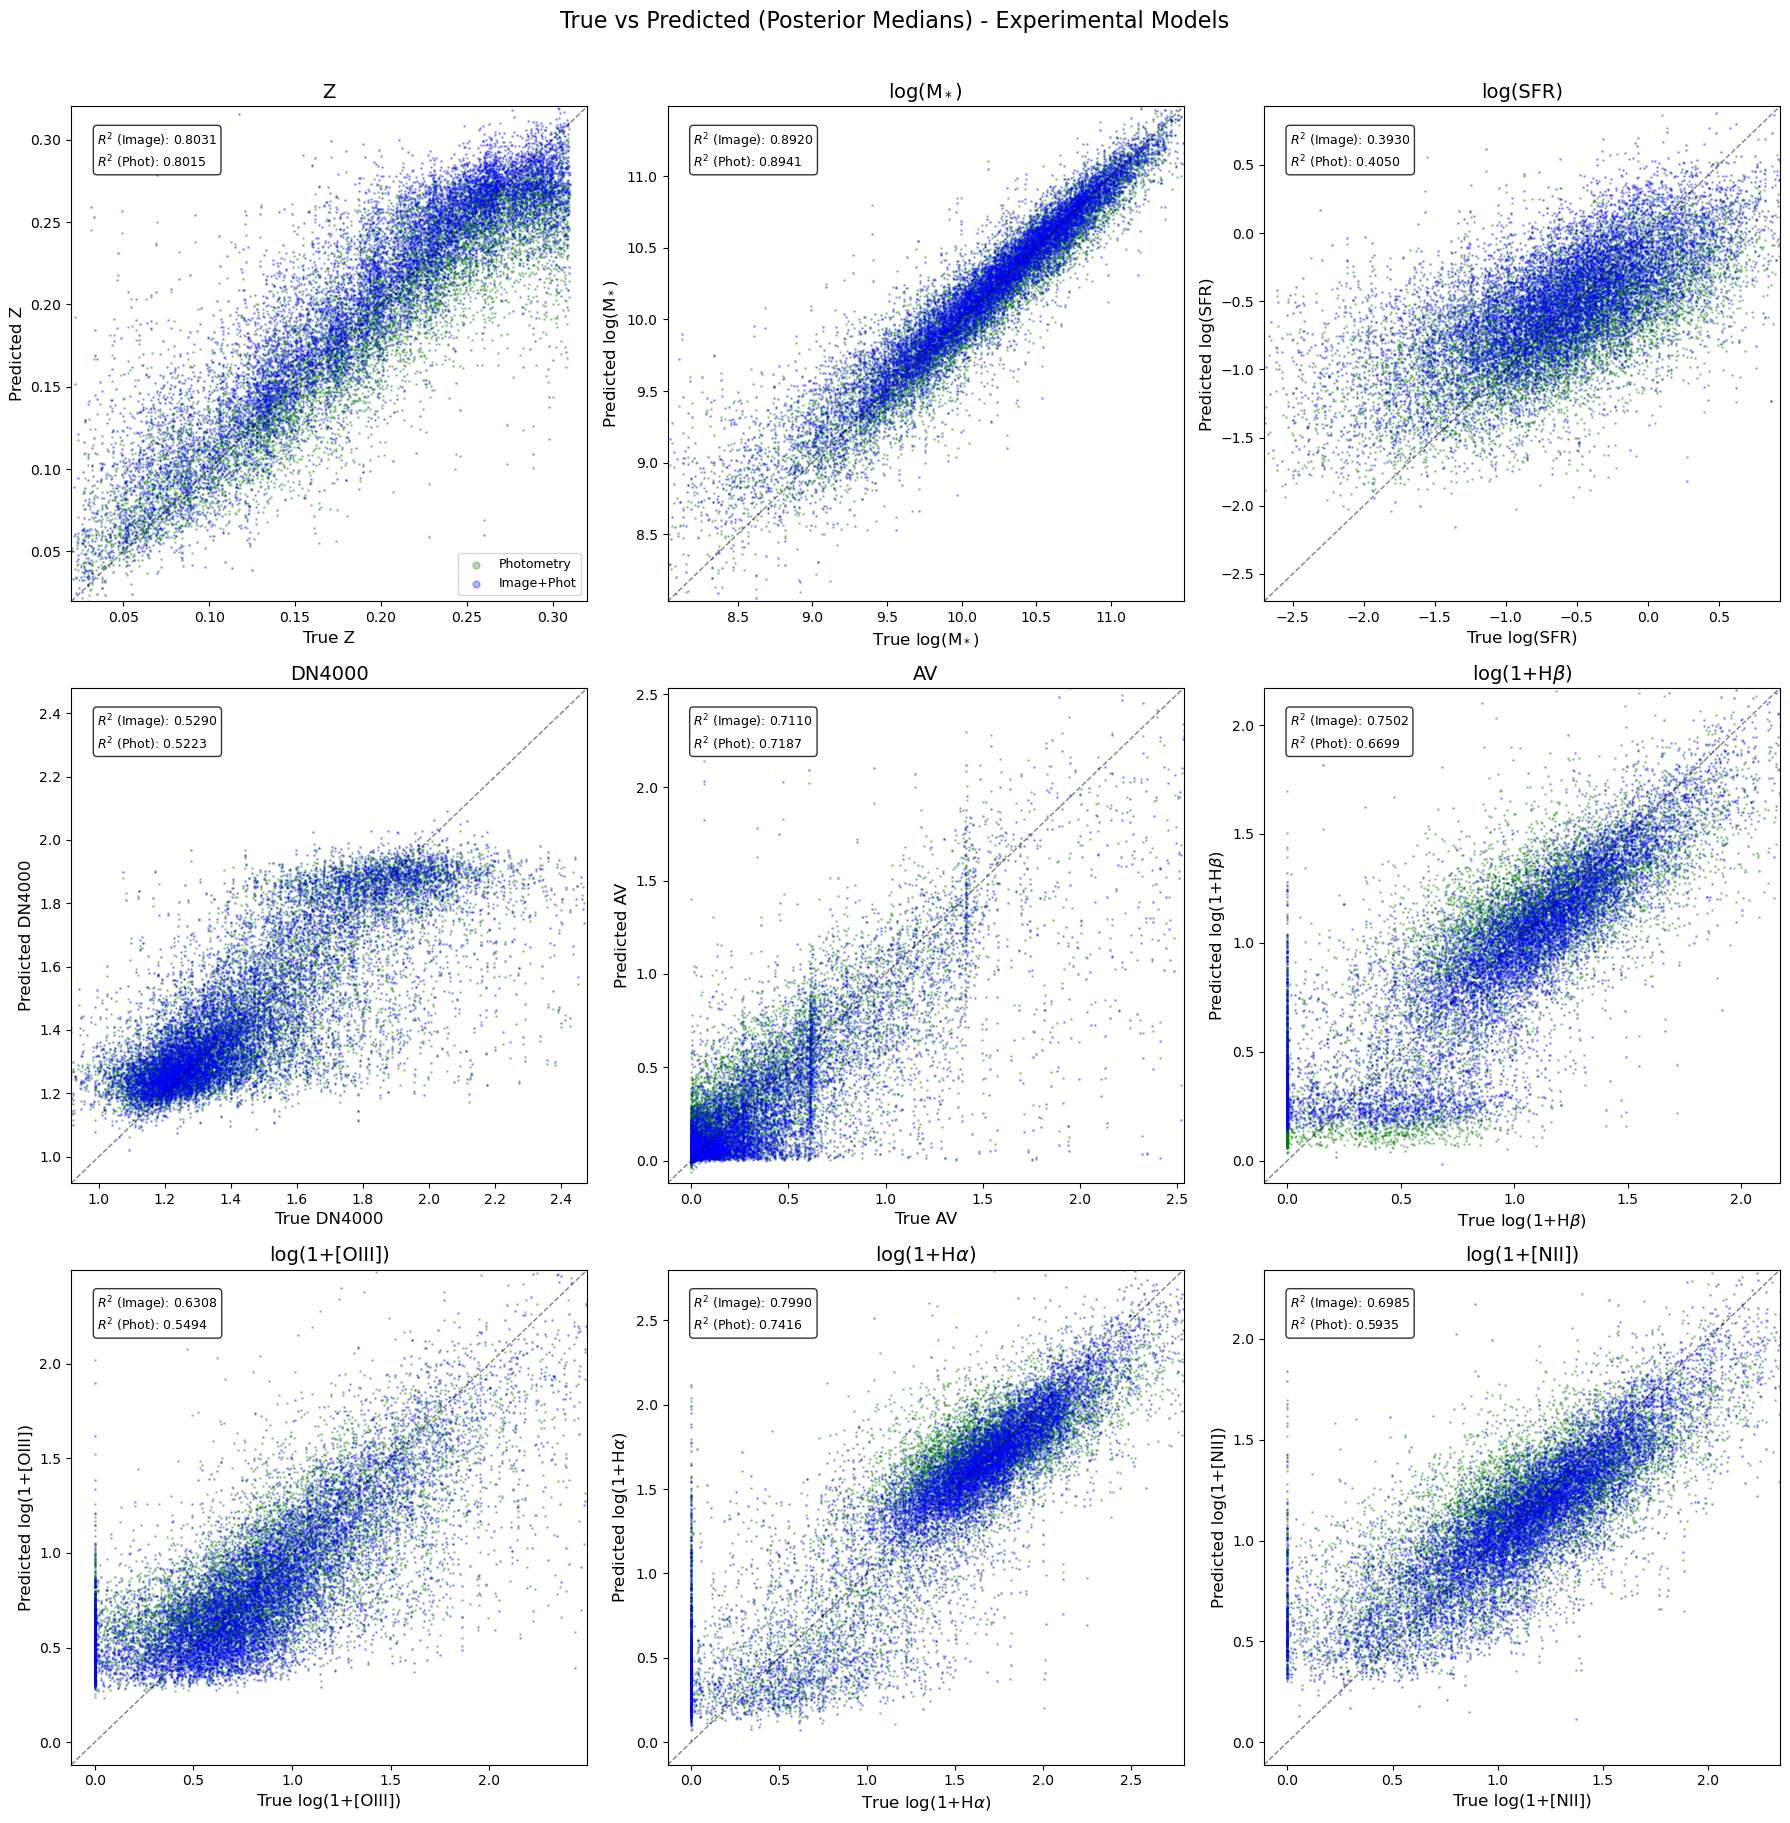

In [14]:
# True vs Predicted scatter plots for all 9 properties
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for j, ax in enumerate(axes.flat):
    true_j = true_values[:, j]
    pred_image_j = image_medians[:, j]
    pred_phot_j = phot_medians[:, j]
    
    # Scatter: image model (blue) and photometry model (green)
    ax.scatter(true_j, pred_phot_j, s=1, alpha=0.3, color='green', label='Photometry', rasterized=True)
    ax.scatter(true_j, pred_image_j, s=1, alpha=0.3, color='blue', label='Image+Phot', rasterized=True)
    
    # 1:1 line
    lo, hi = np.percentile(true_j, [1, 99])
    margin = 0.05 * (hi - lo)
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(lo - margin, hi + margin)
    ax.set_ylim(lo - margin, hi + margin)
    
    ax.set_xlabel(f'True {property_labels[j]}', fontsize=12)
    ax.set_ylabel(f'Predicted {property_labels[j]}', fontsize=12)
    ax.set_title(property_labels[j], fontsize=14)
    
    # Compute and display R^2
    ss_res_image = np.sum((pred_image_j - true_j)**2)
    ss_res_phot = np.sum((pred_phot_j - true_j)**2)
    ss_tot = np.sum((true_j - true_j.mean())**2)
    r2_image = 1 - ss_res_image / ss_tot
    r2_phot = 1 - ss_res_phot / ss_tot
    ax.text(0.05, 0.95, f'$R^2$ (Image): {r2_image:.4f}\n$R^2$ (Phot): {r2_phot:.4f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    if j == 0:
        ax.legend(fontsize=9, loc='lower right', markerscale=5)

fig.suptitle('True vs Predicted (Posterior Medians) - Experimental Models', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Population-Level Corner Plots (Posterior Medians)

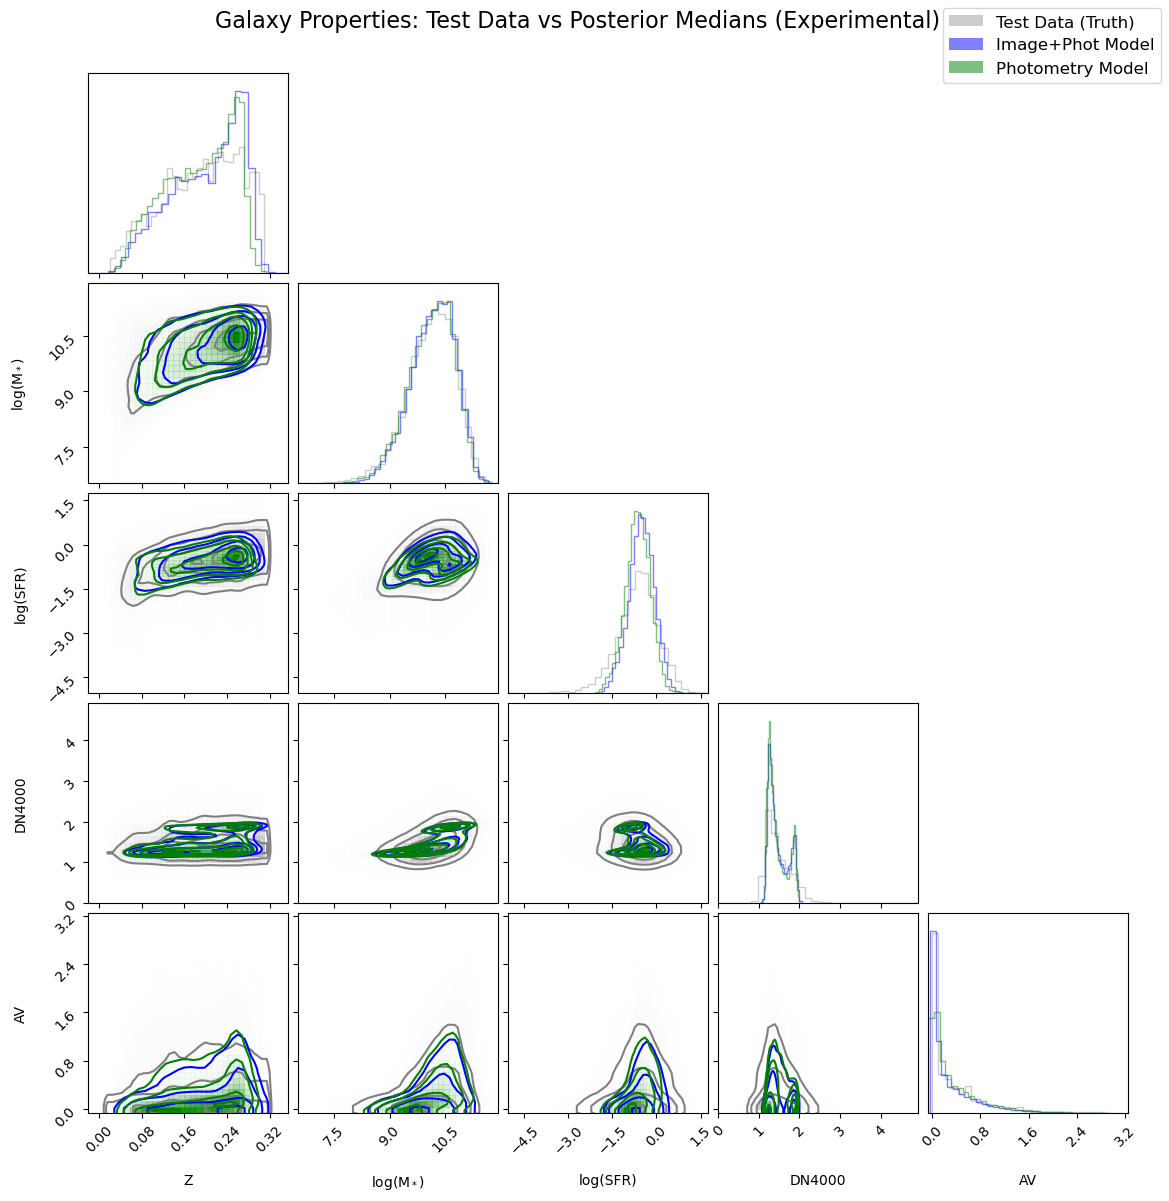

In [15]:
# Corner plot: galaxy properties (first 5)
gal_labels = ['Z', r'log(M$_*$)', 'log(SFR)', 'DN4000', 'AV']

true_gal = true_values[:, :5]
image_gal = image_medians[:, :5]
phot_gal = phot_medians[:, :5]

fig = corner.corner(
    true_gal,
    labels=gal_labels,
    color='gray',
    hist_kwargs={'density': True, 'alpha': 0.4},
    plot_datapoints=False,
    plot_contours=True,
    fill_contours=False,
    smooth=1.0,
    bins=30,
    quiet=True
)

corner.corner(
    image_gal,
    fig=fig,
    color='blue',
    hist_kwargs={'density': True, 'alpha': 0.5},
    plot_datapoints=False,
    plot_contours=True,
    fill_contours=False,
    smooth=1.0,
    bins=30,
    quiet=True
)

corner.corner(
    phot_gal,
    fig=fig,
    color='green',
    hist_kwargs={'density': True, 'alpha': 0.5},
    plot_datapoints=False,
    plot_contours=True,
    fill_contours=False,
    smooth=1.0,
    bins=30,
    quiet=True
)

legend_elements = [
    Patch(facecolor='gray', alpha=0.4, label='Test Data (Truth)'),
    Patch(facecolor='blue', alpha=0.5, label='Image+Phot Model'),
    Patch(facecolor='green', alpha=0.5, label='Photometry Model')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)

fig.suptitle('Galaxy Properties: Test Data vs Posterior Medians (Experimental)', fontsize=16, y=1.02)
plt.show()

Plotting 10130/10130 galaxies (filtered non-finite values)


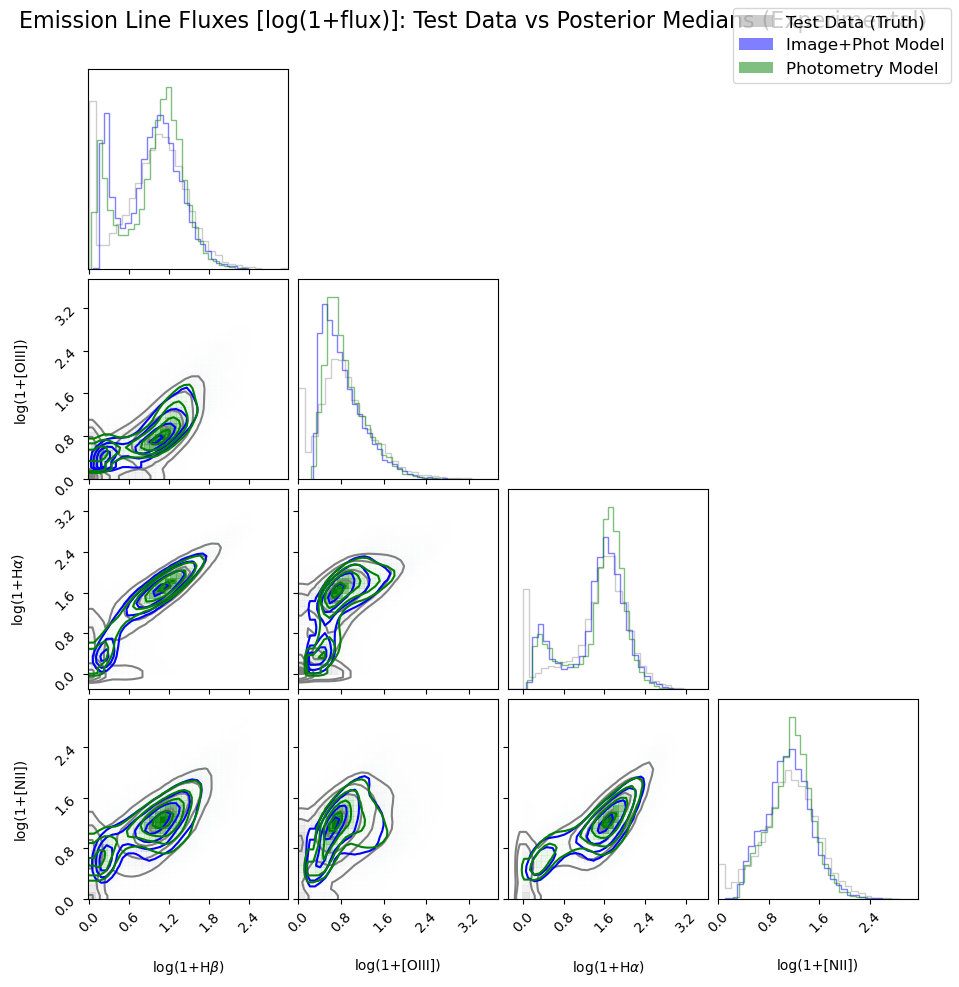

In [16]:
# Corner plot: emission line fluxes (last 4) — already in log(1+flux) space
flux_labels = [r'log(1+H$\beta$)', r'log(1+[OIII])', r'log(1+H$\alpha$)', r'log(1+[NII])']

true_flux = true_values[:, 5:]
image_flux = image_medians[:, 5:]
phot_flux = phot_medians[:, 5:]

# Filter out any non-finite rows
finite_mask = (np.isfinite(true_flux).all(axis=1) &
               np.isfinite(image_flux).all(axis=1) &
               np.isfinite(phot_flux).all(axis=1))
true_flux = true_flux[finite_mask]
image_flux = image_flux[finite_mask]
phot_flux = phot_flux[finite_mask]
print(f"Plotting {finite_mask.sum()}/{len(finite_mask)} galaxies (filtered non-finite values)")

fig = corner.corner(
    true_flux,
    labels=flux_labels,
    color='gray',
    hist_kwargs={'density': True, 'alpha': 0.4},
    plot_datapoints=False,
    plot_contours=True,
    fill_contours=False,
    smooth=1.0,
    bins=30,
    quiet=True
)

corner.corner(
    image_flux,
    fig=fig,
    color='blue',
    hist_kwargs={'density': True, 'alpha': 0.5},
    plot_datapoints=False,
    plot_contours=True,
    fill_contours=False,
    smooth=1.0,
    bins=30,
    quiet=True
)

corner.corner(
    phot_flux,
    fig=fig,
    color='green',
    hist_kwargs={'density': True, 'alpha': 0.5},
    plot_datapoints=False,
    plot_contours=True,
    fill_contours=False,
    smooth=1.0,
    bins=30,
    quiet=True
)

legend_elements = [
    Patch(facecolor='gray', alpha=0.4, label='Test Data (Truth)'),
    Patch(facecolor='blue', alpha=0.5, label='Image+Phot Model'),
    Patch(facecolor='green', alpha=0.5, label='Photometry Model')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)

fig.suptitle('Emission Line Fluxes [log(1+flux)]: Test Data vs Posterior Medians (Experimental)', fontsize=16, y=1.02)
plt.show()

## Dust-Age Degeracy Posterior Quality Metrics: Delta log p and KL Divergence


Population: old_not_dusty (100 galaxies)


Calculating metrics for population size 100: 100%|██████████| 100/100 [11:30<00:00,  6.90s/it]


=== SUMMARY STATISTICS ===
Δ log p (Image+Phot): Mean = 2.399, Std = 2.968
Δ log p (Phot-only):  Mean = 2.397, Std = 3.018
KL divergence (Image+Phot): Mean = 6.970, Std = 0.555
KL divergence (Phot-only):  Mean = 6.592, Std = 0.582



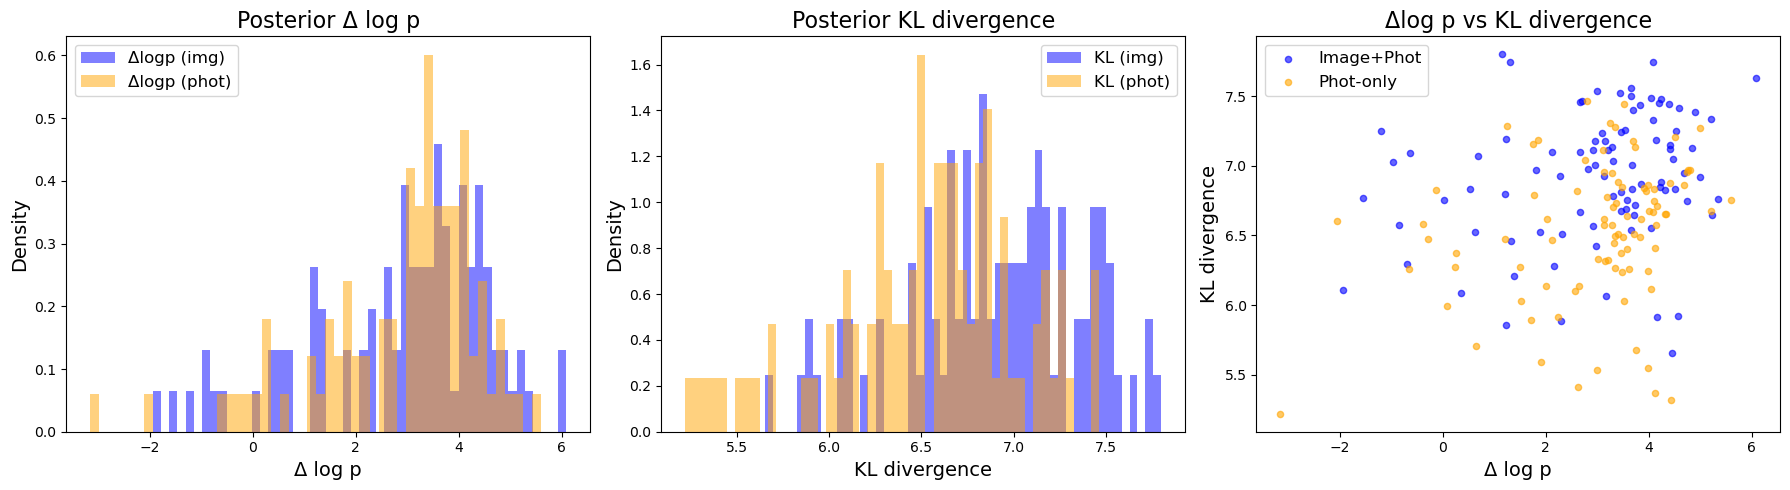


Population: young_dusty (100 galaxies)


Calculating metrics for population size 100: 100%|██████████| 100/100 [11:28<00:00,  6.88s/it]


=== SUMMARY STATISTICS ===
Δ log p (Image+Phot): Mean = -0.979, Std = 23.994
Δ log p (Phot-only):  Mean = 1.093, Std = 9.586
KL divergence (Image+Phot): Mean = 8.934, Std = 1.754
KL divergence (Phot-only):  Mean = 8.485, Std = 1.787



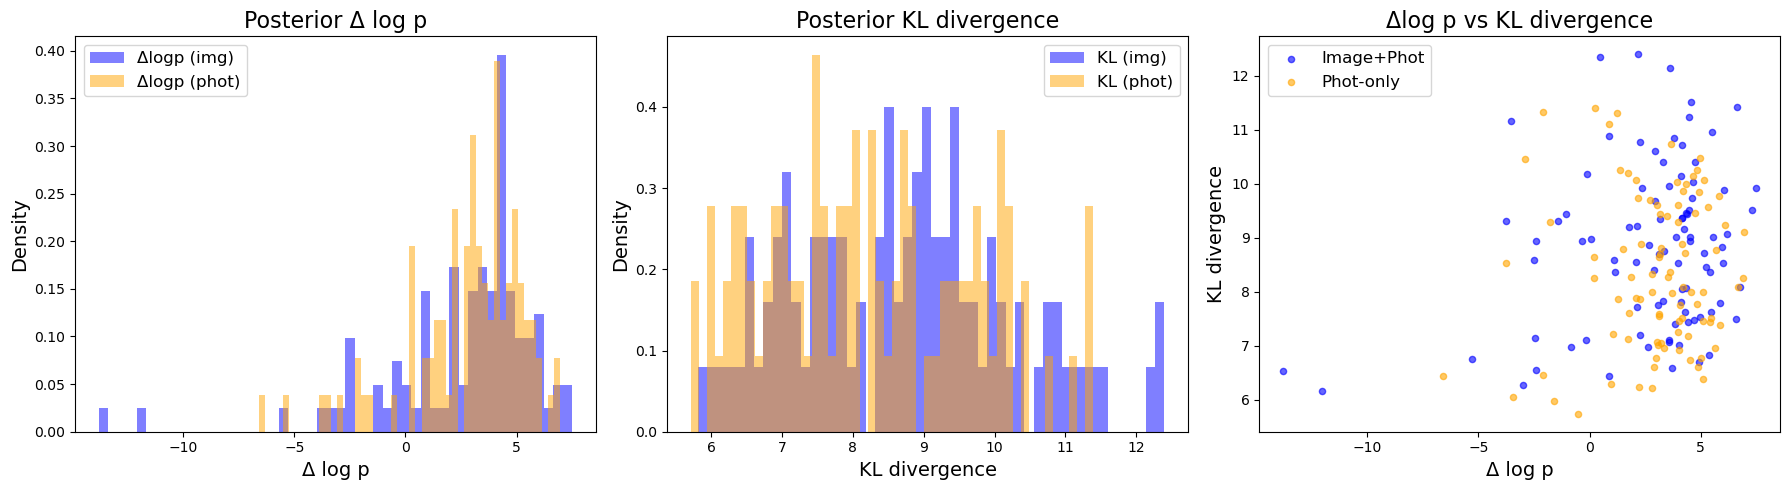

In [20]:
# Compute delta log p and KL divergence for image vs photometry models
def calculate_metrics_for_population(indices, test_ds, img_model, phot_model, all_thetas, prop_mean, prop_std):
    """Calculate posterior quality metrics for a population of galaxies."""
    metrics = []
    num_vars = all_thetas.shape[1]
    for i in tqdm(indices, desc=f"Calculating metrics for population size {len(indices)}"):
        img_tensor, phot_tensor, prop_norm = test_ds[i]
        true_theta = prop_norm.numpy() * prop_std + prop_mean

        img_b = img_tensor.unsqueeze(0).to(device)
        phot_b = phot_tensor.unsqueeze(0).to(device)

        # Sample 1000 posteriors from each model
        samples_image = sample_properties_distribution_rk4(
            img_model, img=img_b, phot=phot_b,
            property_dim=num_vars, num_samples=1000, num_steps=100
        ) * prop_std + prop_mean

        samples_phot = sample_properties_distribution_rk4(
            phot_model, phot=phot_b,
            property_dim=num_vars, num_samples=1000, num_steps=100
        ) * prop_std + prop_mean

        delta_image, kl_image = compute_posterior_metrics(true_theta, samples_image, all_thetas)
        delta_phot, kl_phot = compute_posterior_metrics(true_theta, samples_phot, all_thetas)
        metrics.append([delta_image, kl_image, delta_phot, kl_phot])

    return np.array(metrics)

# Use the same selected galaxies as the individual corner plots
populations = {
    "old_not_dusty": old_selected,
    "young_dusty": young_selected,
}

# Compute and plot metrics for each population
for name, indices in populations.items():
    print(f"\n{'='*60}")
    print(f"Population: {name} ({len(indices)} galaxies)")
    print(f"{'='*60}")
    population_metrics = calculate_metrics_for_population(
        indices, test_dataset, image_model, phot_model, all_thetas, prop_mean, prop_std
    )
    plot_posterior_metrics_histogram(population_metrics, bins=50, plot_outliers=False)

## Dust-Age Degeneracy: Individual Galaxy Corner Plots

In [ ]:
os.makedirs("output_images/dust_age_degeneracy/old_notdusty", exist_ok=True)
# Generate corner plots for OLD, NOT DUSTY galaxies
print(f"Generating corner plots for {len(old_selected)} old, not dusty galaxies...")

for count, i in enumerate(tqdm(old_selected, desc="Old, not dusty")):
    img_tensor, phot_tensor, prop_norm = test_dataset[i]
    true_theta = prop_norm.numpy() * prop_std + prop_mean
    targetid = df_final.iloc[test_idx[i]]['TARGETID']

    img_b = img_tensor.unsqueeze(0).to(device)
    phot_b = phot_tensor.unsqueeze(0).to(device)

    # Sample posteriors from both models
    samples_image = sample_properties_distribution_rk4(
        image_model, img=img_b, phot=phot_b,
        property_dim=num_vars, num_samples=1000, num_steps=100
    ) * prop_std + prop_mean

    samples_phot = sample_properties_distribution_rk4(
        phot_model, phot=phot_b,
        property_dim=num_vars, num_samples=1000, num_steps=100
    ) * prop_std + prop_mean

    try:
        # Create figure with two subfigures: left = properties, right = fluxes + image
        fig = plt.figure(figsize=(30, 14))
        subfigs = fig.subfigures(1, 2, width_ratios=[5, 4], wspace=0.05)

        # --- Left: Galaxy Properties corner plot (5D) ---
        corner.corner(samples_image[:, :5], fig=subfigs[0], labels=prop_corner_labels,
                      range=prop_ranges, color="blue", truths=true_theta[:5], truth_color="red",
                      hist_kwargs={"density": True, "alpha": 0.5},
                      plot_datapoints=False, plot_contours=True, fill_contours=False, quiet=True)

        corner.corner(samples_phot[:, :5], fig=subfigs[0], range=prop_ranges, color="green",
                      hist_kwargs={"density": True, "alpha": 0.5},
                      plot_datapoints=False, plot_contours=True, fill_contours=False, quiet=True)

        subfigs[0].suptitle('Galaxy Properties', fontsize=13, y=0.98)
        for ax in subfigs[0].get_axes():
            ax.tick_params(labelsize=6)

        # --- Right: Emission Line Fluxes corner plot (4D) — already in log(1+flux) space ---
        corner.corner(samples_image[:, 5:], fig=subfigs[1], labels=flux_corner_labels,
                      range=flux_ranges, color="blue", truths=true_theta[5:], truth_color="red",
                      hist_kwargs={"density": True, "alpha": 0.5},
                      plot_datapoints=False, plot_contours=True, fill_contours=False, quiet=True)

        corner.corner(samples_phot[:, 5:], fig=subfigs[1], range=flux_ranges, color="green",
                      hist_kwargs={"density": True, "alpha": 0.5},
                      plot_datapoints=False, plot_contours=True, fill_contours=False, quiet=True)

        subfigs[1].suptitle('Emission Line Fluxes [log(1+flux)]', fontsize=13, y=0.98)
        for ax in subfigs[1].get_axes():
            ax.tick_params(labelsize=6)

        # Galaxy image in the upper-right empty space of the right corner plot
        img_ax = subfigs[1].add_axes([0.50, 0.50, 0.40, 0.40])
        img_ax.imshow(img_tensor.permute(1, 2, 0).numpy())
        img_ax.axis('off')

        # Stats box below image
        stats_ax = subfigs[1].add_axes([0.50, 0.30, 0.40, 0.18])
        stats_ax.axis("off")
        stats_txt = (
            f"OLD, NOT DUSTY\n"
            f"DN4000: {true_theta[3]:.2f}  |  AV: {true_theta[4]:.2f}\n\n"
            f"Blue = Image+Phot\n"
            f"Green = Phot only\n"
            f"Red = Truth"
        )
        stats_ax.text(0.05, 0.5, stats_txt, fontsize=10, va="center",
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        fig.suptitle(f"OLD, NOT DUSTY - TARGETID {int(targetid)} (Experimental)",
                     fontsize=15, fontweight='bold', y=1.01)

        out_path = f"output_images/dust_age_degeneracy/old_notdusty/old_not_dusty_{count:03d}_targetid_{int(targetid)}.png"
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close(fig)

    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"\nSkipping galaxy {count} (TARGETID {int(targetid)}): {str(e)}")
        plt.close('all')
        continue

print(f"Saved {len(old_selected)} corner plots to output_images/dust_age_degeneracy/old_notdusty/")

In [ ]:
os.makedirs("output_images/dust_age_degeneracy/young_dusty", exist_ok=True)
# Generate corner plots for YOUNG, DUSTY galaxies
print(f"Generating corner plots for {len(young_selected)} young, dusty galaxies...")

for count, i in enumerate(tqdm(young_selected, desc="Young, dusty")):
    img_tensor, phot_tensor, prop_norm = test_dataset[i]
    true_theta = prop_norm.numpy() * prop_std + prop_mean
    targetid = df_final.iloc[test_idx[i]]['TARGETID']

    img_b = img_tensor.unsqueeze(0).to(device)
    phot_b = phot_tensor.unsqueeze(0).to(device)

    # Sample posteriors from both models
    samples_image = sample_properties_distribution_rk4(
        image_model, img=img_b, phot=phot_b,
        property_dim=num_vars, num_samples=1000, num_steps=100
    ) * prop_std + prop_mean

    samples_phot = sample_properties_distribution_rk4(
        phot_model, phot=phot_b,
        property_dim=num_vars, num_samples=1000, num_steps=100
    ) * prop_std + prop_mean

    try:
        # Create figure with two subfigures: left = properties, right = fluxes + image
        fig = plt.figure(figsize=(30, 14))
        subfigs = fig.subfigures(1, 2, width_ratios=[5, 4], wspace=0.05)

        # --- Left: Galaxy Properties corner plot (5D) ---
        corner.corner(samples_image[:, :5], fig=subfigs[0], labels=prop_corner_labels,
                      range=prop_ranges, color="blue", truths=true_theta[:5], truth_color="red",
                      hist_kwargs={"density": True, "alpha": 0.5},
                      plot_datapoints=False, plot_contours=True, fill_contours=False, quiet=True)

        corner.corner(samples_phot[:, :5], fig=subfigs[0], range=prop_ranges, color="green",
                      hist_kwargs={"density": True, "alpha": 0.5},
                      plot_datapoints=False, plot_contours=True, fill_contours=False, quiet=True)

        subfigs[0].suptitle('Galaxy Properties', fontsize=13, y=0.98)
        for ax in subfigs[0].get_axes():
            ax.tick_params(labelsize=6)

        # --- Right: Emission Line Fluxes corner plot (4D) — already in log(1+flux) space ---
        corner.corner(samples_image[:, 5:], fig=subfigs[1], labels=flux_corner_labels,
                      range=flux_ranges, color="blue", truths=true_theta[5:], truth_color="red",
                      hist_kwargs={"density": True, "alpha": 0.5},
                      plot_datapoints=False, plot_contours=True, fill_contours=False, quiet=True)

        corner.corner(samples_phot[:, 5:], fig=subfigs[1], range=flux_ranges, color="green",
                      hist_kwargs={"density": True, "alpha": 0.5},
                      plot_datapoints=False, plot_contours=True, fill_contours=False, quiet=True)

        subfigs[1].suptitle('Emission Line Fluxes [log(1+flux)]', fontsize=13, y=0.98)
        for ax in subfigs[1].get_axes():
            ax.tick_params(labelsize=6)

        # Galaxy image in the upper-right empty space of the right corner plot
        img_ax = subfigs[1].add_axes([0.50, 0.50, 0.40, 0.40])
        img_ax.imshow(img_tensor.permute(1, 2, 0).numpy())
        img_ax.axis('off')

        # Stats box below image
        stats_ax = subfigs[1].add_axes([0.50, 0.30, 0.40, 0.18])
        stats_ax.axis("off")
        stats_txt = (
            f"YOUNG, DUSTY\n"
            f"DN4000: {true_theta[3]:.2f}  |  AV: {true_theta[4]:.2f}\n\n"
            f"Blue = Image+Phot\n"
            f"Green = Phot only\n"
            f"Red = Truth"
        )
        stats_ax.text(0.05, 0.5, stats_txt, fontsize=10, va="center",
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        fig.suptitle(f"YOUNG, DUSTY - TARGETID {int(targetid)} (Experimental)",
                     fontsize=15, fontweight='bold', y=1.01)

        out_path = f"output_images/dust_age_degeneracy/young_dusty/young_dusty_{count:03d}_targetid_{int(targetid)}.png"
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close(fig)

    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"\nSkipping galaxy {count} (TARGETID {int(targetid)}): {str(e)}")
        plt.close('all')
        continue

print(f"Saved {len(young_selected)} corner plots to output_images/dust_age_degeneracy/young_dusty/")

# Single-Trajectory Predictions

Instead of sampling 1000 trajectories and taking the posterior median, sample **one** trajectory per galaxy from the learned flow (using RK4) and treat that as the point estimate. This shows how well a single draw from the model performs.

In [21]:
# Sample a single trajectory per test galaxy from each model
print(f"Sampling single trajectories for {N_test} test galaxies...")

image_single = np.zeros((N_test, num_vars))
phot_single = np.zeros((N_test, num_vars))

for i in tqdm(range(N_test), desc="Single-trajectory sampling"):
    img_tensor, phot_tensor, prop_norm = test_dataset[i]
    
    img_b = img_tensor.unsqueeze(0).to(device)
    phot_b = phot_tensor.unsqueeze(0).to(device)
    
    # Single trajectory from image model
    pred_image = sample_properties_rk4(
        image_model, img=img_b, phot=phot_b,
        property_dim=num_vars, num_steps=100
    )
    image_single[i] = (pred_image.cpu().numpy().squeeze()) * prop_std + prop_mean
    
    # Single trajectory from photometry model
    pred_phot = sample_properties_rk4(
        phot_model, phot=phot_b,
        property_dim=num_vars, num_steps=100
    )
    phot_single[i] = (pred_phot.cpu().numpy().squeeze()) * prop_std + prop_mean

print(f"\nDone! Single-trajectory predictions for {N_test} test galaxies.")

Sampling single trajectories for 10130 test galaxies...


Single-trajectory sampling: 100%|██████████| 10130/10130 [55:31<00:00,  3.04it/s]


Done! Single-trajectory predictions for 10130 test galaxies.


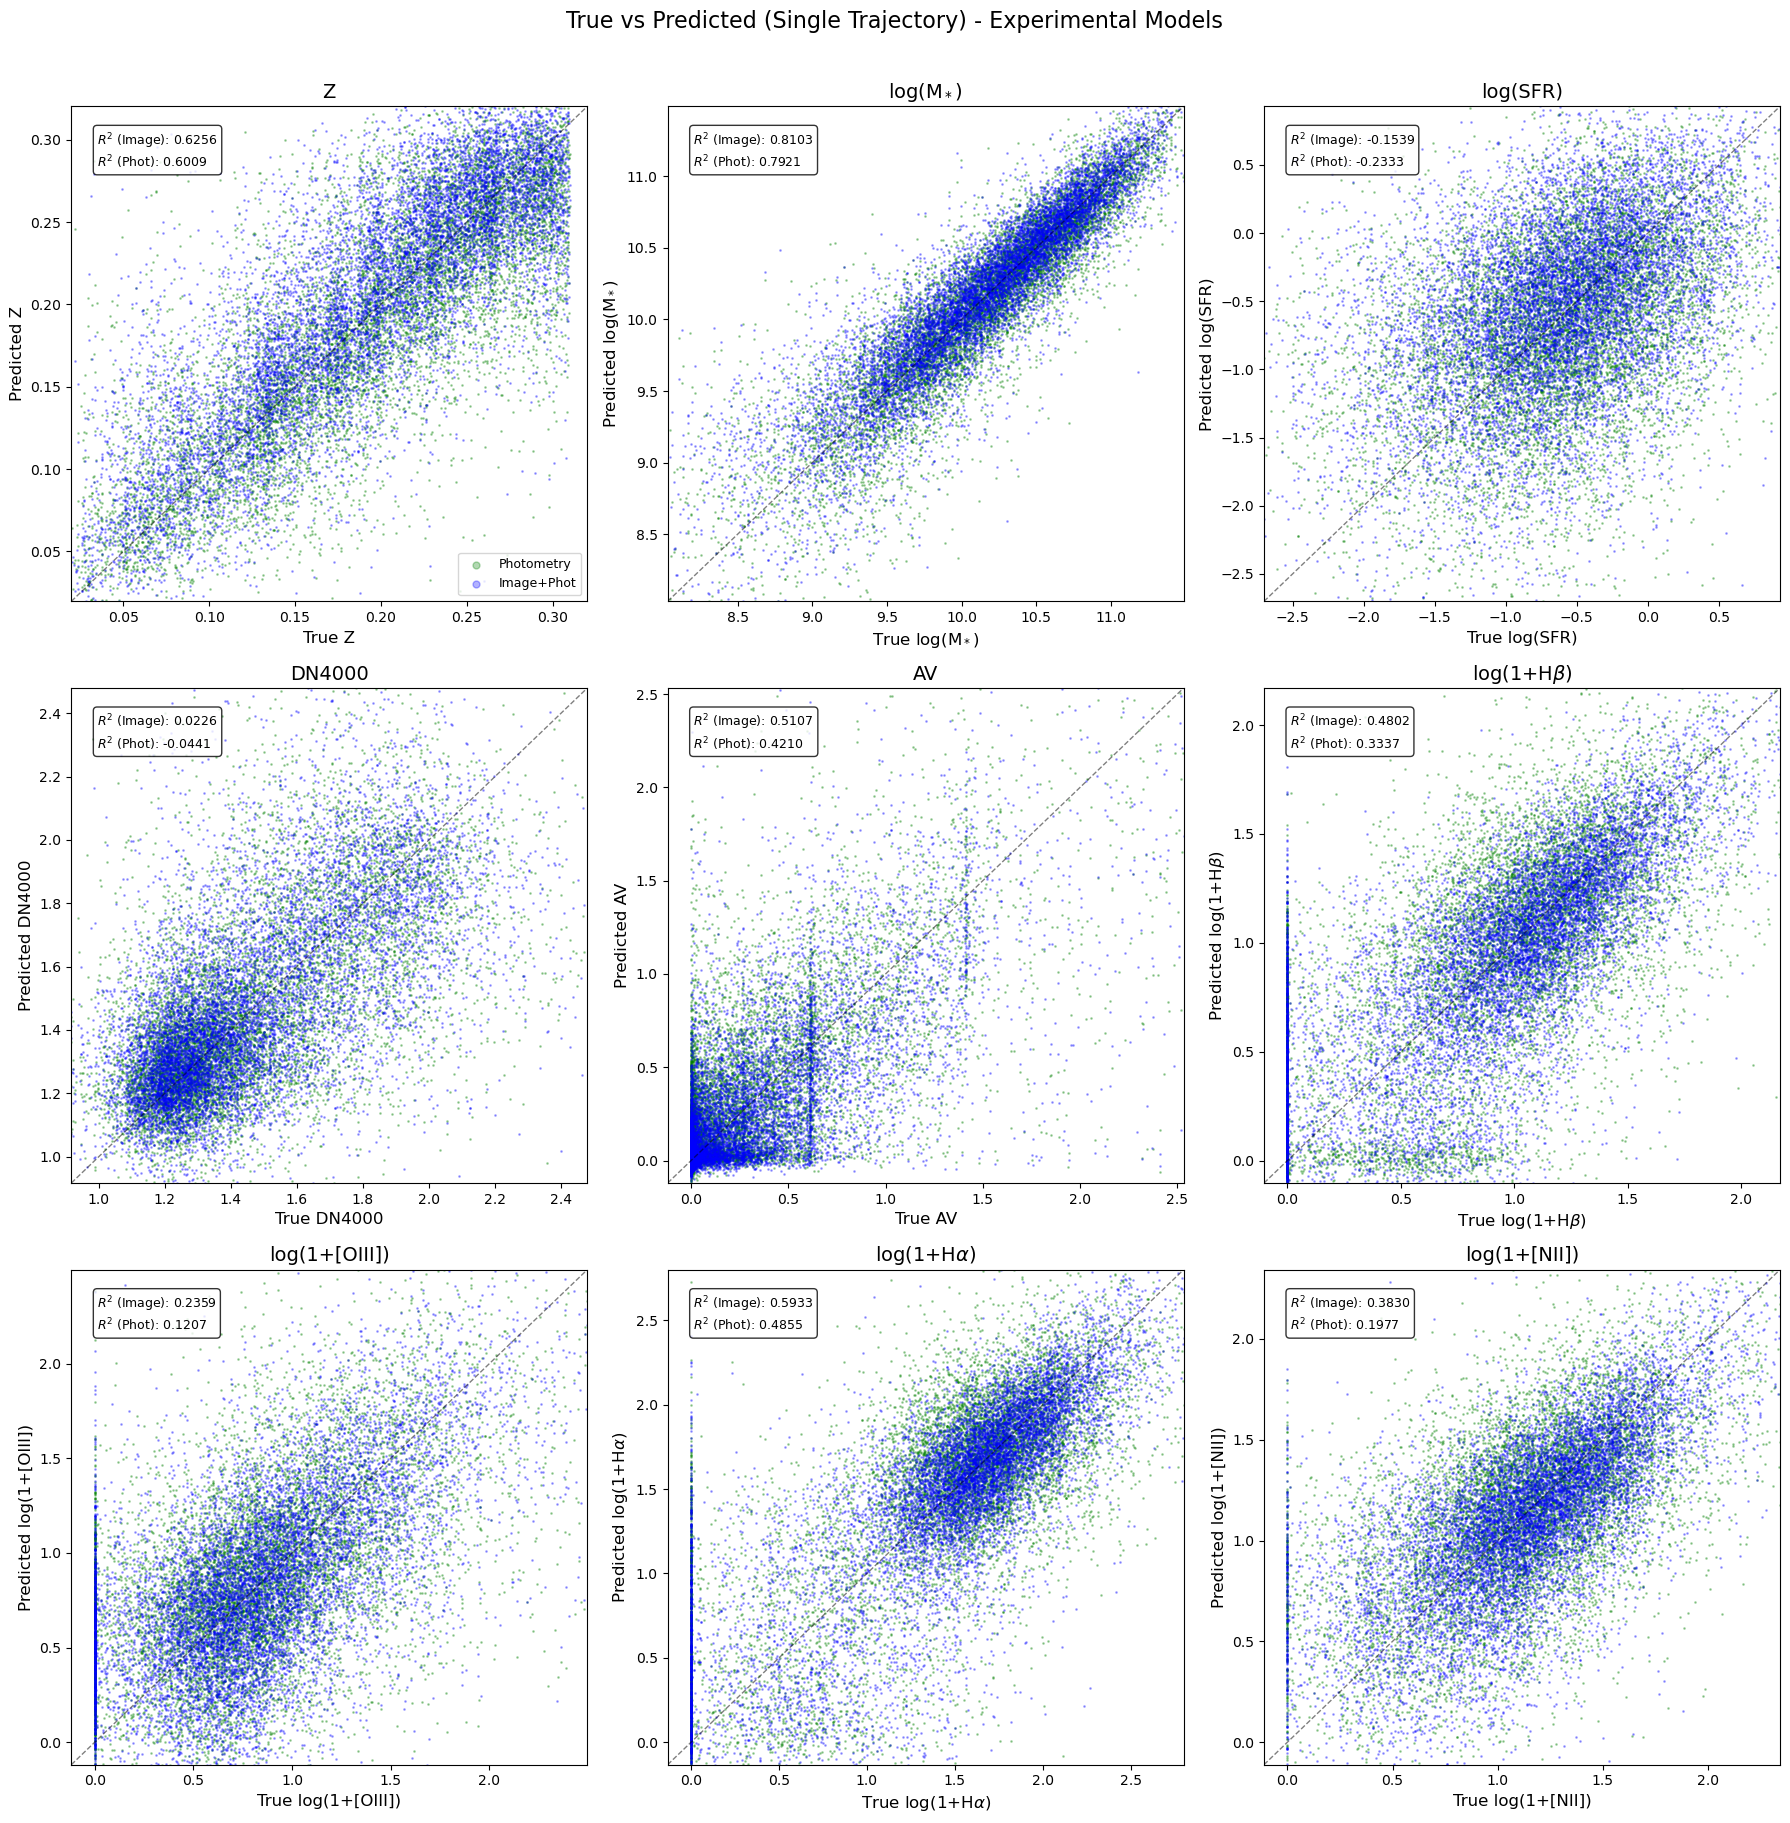

In [22]:
# True vs Predicted scatter plots — single trajectory
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for j, ax in enumerate(axes.flat):
    true_j = true_values[:, j]
    pred_image_j = image_single[:, j]
    pred_phot_j = phot_single[:, j]
    
    ax.scatter(true_j, pred_phot_j, s=1, alpha=0.3, color='green', label='Photometry', rasterized=True)
    ax.scatter(true_j, pred_image_j, s=1, alpha=0.3, color='blue', label='Image+Phot', rasterized=True)
    
    lo, hi = np.percentile(true_j, [1, 99])
    margin = 0.05 * (hi - lo)
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(lo - margin, hi + margin)
    ax.set_ylim(lo - margin, hi + margin)
    
    ax.set_xlabel(f'True {property_labels[j]}', fontsize=12)
    ax.set_ylabel(f'Predicted {property_labels[j]}', fontsize=12)
    ax.set_title(property_labels[j], fontsize=14)
    
    ss_res_image = np.sum((pred_image_j - true_j)**2)
    ss_res_phot = np.sum((pred_phot_j - true_j)**2)
    ss_tot = np.sum((true_j - true_j.mean())**2)
    r2_image = 1 - ss_res_image / ss_tot
    r2_phot = 1 - ss_res_phot / ss_tot
    ax.text(0.05, 0.95, f'$R^2$ (Image): {r2_image:.4f}\n$R^2$ (Phot): {r2_phot:.4f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    if j == 0:
        ax.legend(fontsize=9, loc='lower right', markerscale=5)

fig.suptitle('True vs Predicted (Single Trajectory) - Experimental Models', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Population-Level Corner Plots (Single Trajectory)

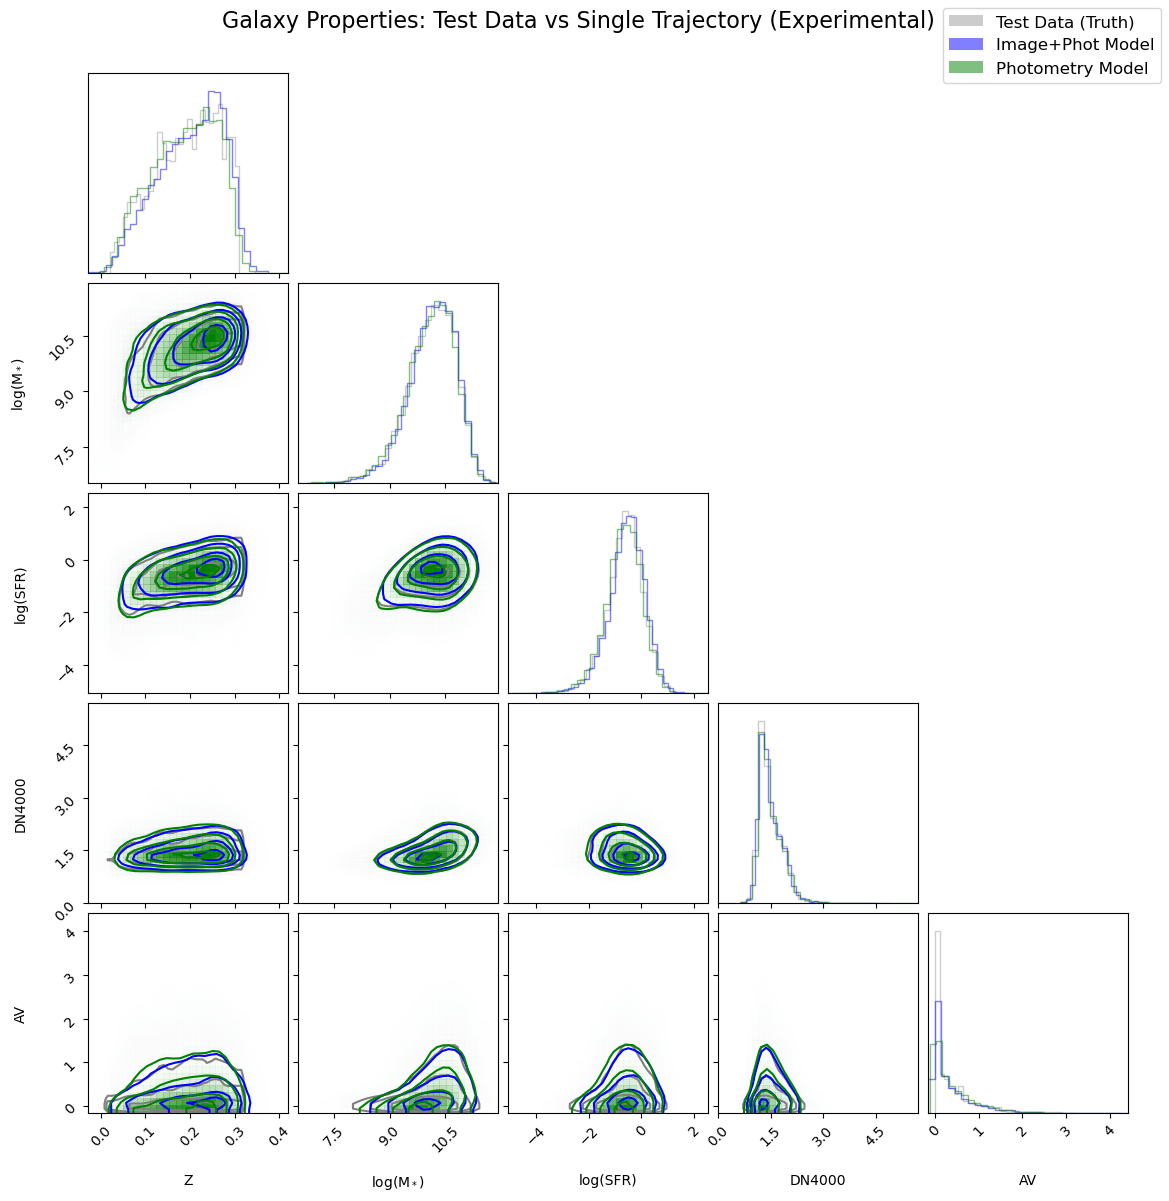

In [23]:
# Corner plot: galaxy properties (first 5) — single trajectory
gal_labels = ['Z', r'log(M$_*$)', 'log(SFR)', 'DN4000', 'AV']

true_gal_st = true_values[:, :5]
image_gal_st = image_single[:, :5]
phot_gal_st = phot_single[:, :5]

fig = corner.corner(
    true_gal_st, labels=gal_labels, color='gray',
    hist_kwargs={'density': True, 'alpha': 0.4},
    plot_datapoints=False, plot_contours=True, fill_contours=False,
    smooth=1.0, bins=30, quiet=True
)

corner.corner(
    image_gal_st, fig=fig, color='blue',
    hist_kwargs={'density': True, 'alpha': 0.5},
    plot_datapoints=False, plot_contours=True, fill_contours=False,
    smooth=1.0, bins=30, quiet=True
)

corner.corner(
    phot_gal_st, fig=fig, color='green',
    hist_kwargs={'density': True, 'alpha': 0.5},
    plot_datapoints=False, plot_contours=True, fill_contours=False,
    smooth=1.0, bins=30, quiet=True
)

legend_elements = [
    Patch(facecolor='gray', alpha=0.4, label='Test Data (Truth)'),
    Patch(facecolor='blue', alpha=0.5, label='Image+Phot Model'),
    Patch(facecolor='green', alpha=0.5, label='Photometry Model')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)

fig.suptitle('Galaxy Properties: Test Data vs Single Trajectory (Experimental)', fontsize=16, y=1.02)
plt.show()

Plotting 10130/10130 galaxies (filtered non-finite values)


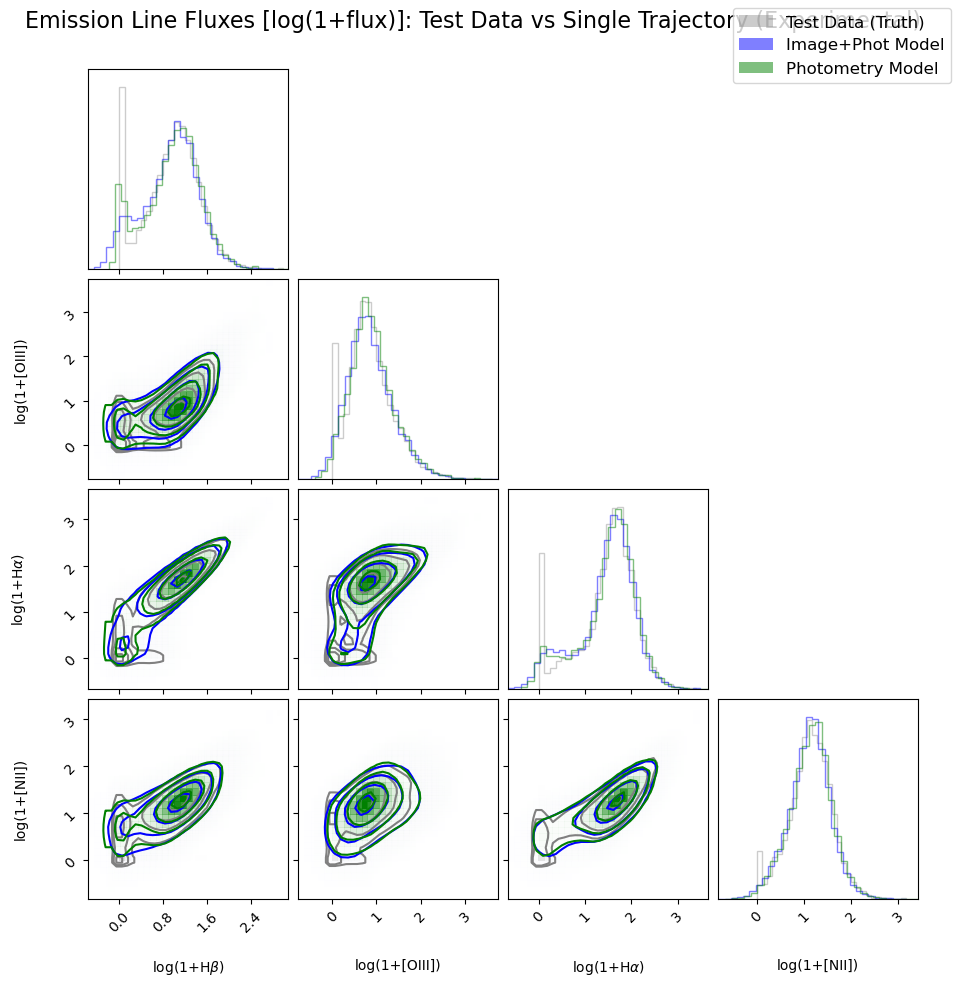

In [24]:
# Corner plot: emission line fluxes (last 4) — already in log(1+flux) space — single trajectory
flux_labels_st = [r'log(1+H$\beta$)', r'log(1+[OIII])', r'log(1+H$\alpha$)', r'log(1+[NII])']

true_flux_st = true_values[:, 5:]
image_flux_st = image_single[:, 5:]
phot_flux_st = phot_single[:, 5:]

finite_mask_st = (np.isfinite(true_flux_st).all(axis=1) &
                  np.isfinite(image_flux_st).all(axis=1) &
                  np.isfinite(phot_flux_st).all(axis=1))
true_flux_st = true_flux_st[finite_mask_st]
image_flux_st = image_flux_st[finite_mask_st]
phot_flux_st = phot_flux_st[finite_mask_st]
print(f"Plotting {finite_mask_st.sum()}/{len(finite_mask_st)} galaxies (filtered non-finite values)")

fig = corner.corner(
    true_flux_st, labels=flux_labels_st, color='gray',
    hist_kwargs={'density': True, 'alpha': 0.4},
    plot_datapoints=False, plot_contours=True, fill_contours=False,
    smooth=1.0, bins=30, quiet=True
)

corner.corner(
    image_flux_st, fig=fig, color='blue',
    hist_kwargs={'density': True, 'alpha': 0.5},
    plot_datapoints=False, plot_contours=True, fill_contours=False,
    smooth=1.0, bins=30, quiet=True
)

corner.corner(
    phot_flux_st, fig=fig, color='green',
    hist_kwargs={'density': True, 'alpha': 0.5},
    plot_datapoints=False, plot_contours=True, fill_contours=False,
    smooth=1.0, bins=30, quiet=True
)

legend_elements = [
    Patch(facecolor='gray', alpha=0.4, label='Test Data (Truth)'),
    Patch(facecolor='blue', alpha=0.5, label='Image+Phot Model'),
    Patch(facecolor='green', alpha=0.5, label='Photometry Model')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)

fig.suptitle('Emission Line Fluxes [log(1+flux)]: Test Data vs Single Trajectory (Experimental)', fontsize=16, y=1.02)
plt.show()